In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [12]:
data = pd.read_csv("Aemf1.csv")
print(data.isnull().sum())


City                           0
Price                          0
Day                            0
Room Type                      0
Shared Room                    0
Private Room                   0
Person Capacity                0
Superhost                      0
Multiple Rooms                 0
Business                       0
Cleanliness Rating             0
Guest Satisfaction             0
Bedrooms                       0
City Center (km)               0
Metro Distance (km)            0
Attraction Index               0
Normalised Attraction Index    0
Restraunt Index                0
Normalised Restraunt Index     0
dtype: int64


In [13]:
for col in data.columns:
    data[col] = data[col].replace(['ERROR', 'UNKNOWN'], np.nan)

In [14]:
data = data.drop('Day', axis=1)
data_clone = data.copy()
data.head()



,City,Price,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677


In [15]:
print(data['Room Type'].dtype)

str


In [16]:
shared={False:0,True:1}
data['Private Room'] = data['Private Room'].map(shared)
data['Shared Room'] = data['Shared Room'].map(shared)
data['Superhost'] = data['Superhost'].map(shared)

data['Room Type'].unique()
data['Room Type']=data['Room Type'].astype(str)
type={'Private room':1, 'Entire home/apt':2, 'Shared room':3}
data['Room Type'] = data['Room Type'].map(type)

# data.head()

In [17]:
data.drop_duplicates(inplace=True)


In [18]:
data['City'].unique()
data['City']=data['City'].astype(str)
cityy={'Amsterdam':1,    'Athens':2, 'Barcelona':3,    'Berlin':4,  'Budapest':5,    'Lisbon':6,
     'Paris':7,      'Rome':8,    'Vienna':9}
#data['City']=data['City'].map(cityy)
data.head()

,City,Price,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,1,0,1,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,1,0,1,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,1,0,1,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,1,0,1,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,1,0,1,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677


In [ ]:
min_count = data['City'].value_counts().min()

balanced_list = []
for city, group in data.groupby('City'):
    balanced_list.append(group.sample(min_count))
data_balanced = pd.concat(balanced_list).reset_index(drop=True)




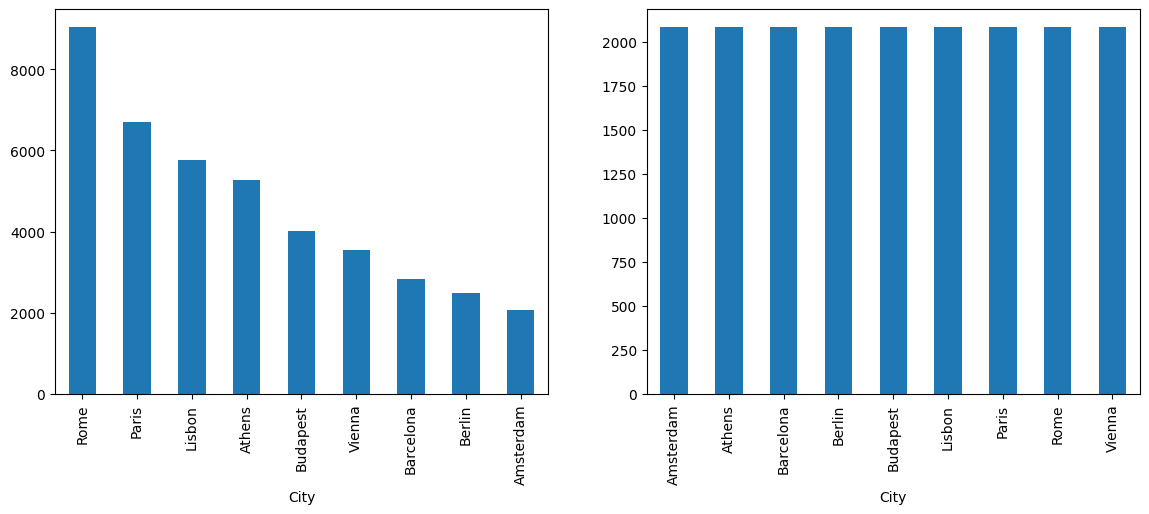

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data['City'].value_counts().plot(kind='bar', ax=axes[0])
data_balanced['City'].value_counts().plot(kind='bar', ax=axes[1])

plt.show()